### **Cuaderno 8 - Atención intermodal en secuencias multimodales no alineadas: de fusión tardía a MulT-lite y SPT-lite**


Este cuaderno estudia un problema central del aprendizaje multimodal avanzado: **cómo modelar dependencias entre modalidades cuando sus secuencias no están alineadas temporalmente**. A diferencia de los enfoques de fusión clásica, donde texto, audio y video se resumen por separado y se combinan al final, aquí el interés está en analizar arquitecturas que permiten **interacción explícita entre modalidades a lo largo del tiempo**.

El punto de partida es un baseline de la **fusión tardía**, útil como referencia porque separa el modelado unimodal de la etapa de decisión. Sin embargo, este enfoque puede perder información relevante cuando la evidencia semántica aparece desfasada entre modalidades. Para abordar esa limitación, el cuaderno introduce **MulT-lite**, una versión simplificada de atención intermodal dirigida, donde una modalidad puede consultar dinámicamente a otra sin requerir correspondencia temporal exacta. Esta idea permite capturar relaciones asincrónicas, que son frecuentes en escenarios reales como análisis de discurso, emoción o sentimiento multimodal.

A continuación, se presenta **SPT-lite**, que conserva la lógica de interacción multimodal, pero incorpora una estrategia más eficiente basada en **en estados ocultos comprimidos**, junto con etapas de **Input Attention, Cross Attention y Self Attention**. Su motivación es reducir costo computacional sin renunciar por completo a la capacidad de modelar interacciones ricas entre modalidades.

En conjunto, el cuaderno compara tres niveles de complejidad: **fusión tardía, atención intermodal completa y atención intermodal comprimida**. El objetivo no es solo observar qué modelo obtiene mejores métricas, sino entender el compromiso entre **capacidad de alineamiento, costo computacional e interpretabilidad**, especialmente mediante curvas de entrenamiento, tablas comparativas y visualización de atención en MulT-lite.


In [1]:
# 0. Setup

import math
import random
import time
from dataclasses import dataclass, asdict
from typing import Dict, List, Any, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

def resolve_device(preference="auto"):
    preference = preference.lower().strip()
    if preference == "auto":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if preference == "cuda":
        if torch.cuda.is_available():
            return torch.device("cuda")
        print("CUDA no disponible, usando CPU.")
        return torch.device("cpu")
    return torch.device("cpu")

print("Torch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.4.1+cpu
CUDA disponible: False


#### **1. Configuración**

La configuración de este cuaderno fue ajustada para que la comparación entre modelos sea más estable e interpretable desde una perspectiva experimental. En particular, se incrementó el número de épocas para observar trayectorias de aprendizaje menos triviales, se adoptó una tasa de aprendizaje más conservadora y se incorporó **gradient clipping** para reducir inestabilidades numéricas. Además, el dataset sintético se redefinió con **prototipos por clase**, de modo que la tarea conserve el carácter de secuencias no alineadas, pero con una señal estructural suficientemente consistente como para comparar arquitecturas de forma razonable.

También se incorporó evaluación separada en **validación** y **test**, lo que permite distinguir entre ajuste durante entrenamiento y capacidad de generalización. Finalmente, el cuaderno registra explícitamente el **costo computacional** de cada modelo, incluyendo conteo de parámetros y tiempo por época, para que la comparación no se limite solo a métricas de rendimiento, sino también a la relación entre capacidad, eficiencia e interpretabilidad.

In [2]:
# 1. Configuración

@dataclass
class Config:
    device_preference: str = "auto"
    batch_size: int = 8
    num_workers: int = 0

    vocab_size: int = 2048
    num_classes: int = 3

    d_model: int = 128
    num_heads: int = 4
    ff_mult: int = 4
    num_layers: int = 2
    dropout: float = 0.1

    max_text_len: int = 14
    max_audio_len: int = 48
    max_video_len: int = 24

    train_size: int = 256
    val_size: int = 64
    test_size: int = 64

    epochs: int = 8
    lr: float = 5e-4
    weight_decay: float = 1e-4
    grad_clip: float = 1.0

    hidden_ratio: int = 4

CFG = Config()
DEVICE = resolve_device(CFG.device_preference)
CFG

Config(device_preference='auto', batch_size=8, num_workers=0, vocab_size=2048, num_classes=3, d_model=128, num_heads=4, ff_mult=4, num_layers=2, dropout=0.1, max_text_len=14, max_audio_len=48, max_video_len=24, train_size=256, val_size=64, test_size=64, epochs=8, lr=0.0005, weight_decay=0.0001, grad_clip=1.0, hidden_ratio=4)

#### **2. Dataset sintético no alineado**

El cuaderno utiliza un **dataset sintético de secuencias no alineadas** diseñado para aislar la estructura conceptual del problema sin depender todavía de un benchmark real. Cada ejemplo contiene tres modalidades, **texto, audio y video**, cada una con su propia longitud y con una región local informativa. La dificultad central es que esas regiones relevantes **no coinciden exactamente en el tiempo**: pueden tener distinta duración, aparecer en posiciones diferentes y solo estar conectadas por una **señal latente de clase** compartida.

Esta construcción permite simular un escenario multimodal más realista que la simple fusión de embeddings globales, porque obliga al modelo a decidir **dónde buscar evidencia útil en cada modalidad** aun cuando las pistas no estén sincronizadas. Para que la tarea siga siendo exigente pero no arbitraria, el dataset incorpora una estructura controlada: **marcadores de clase en texto**, **prototipos de clase en audio y video**, y **ruido moderado fuera de los segmentos informativos**. Así, el problema conserva el desalineamiento temporal como dificultad principal, pero con una señal suficientemente estable como para comparar arquitecturas de manera metodológicamente razonable.


##Notas al código
se crean vectores representativos para cada clase.
audio_proto = torch.randn
Ejemplo: 
Clase 0 → bailar
Clase 1 → tocar batería
Clase 2 → correr
El +0.8 aumenta la intensidad de la señal asociada a la clase dentro del segmento relevante.
collate_unaligned: Convierte varias muestras en un batch.

In [3]:
# 2. Dataset sintético no alineado

def lengths_to_mask(lengths: torch.Tensor, max_len: int) -> torch.Tensor:
    ar = torch.arange(max_len).unsqueeze(0)
    return ar < lengths.unsqueeze(1)

class SyntheticUnalignedMultimodalDataset(Dataset):
    def __init__(self, size: int, cfg: Config, split: str = "train"):
        self.size = size
        self.cfg = cfg
        self.split = split

        self.text_markers = [(c + 1) * 10 for c in range(cfg.num_classes)]
        self.audio_proto = torch.randn(cfg.num_classes, cfg.d_model) * 0.5
        self.video_proto = torch.randn(cfg.num_classes, cfg.d_model) * 0.5

        self.samples = [self._make_sample(i) for i in range(size)]

    def _make_segment(self, L, min_len=2):
        seg_len = random.randint(min_len, max(min_len, L // 3))
        start = random.randint(0, max(0, L - seg_len))
        end = min(L, start + seg_len)
        return start, end

    def _make_sample(self, idx: int):
        Lt = random.randint(max(5, self.cfg.max_text_len // 2), self.cfg.max_text_len)
        La = random.randint(max(12, self.cfg.max_audio_len // 2), self.cfg.max_audio_len)
        Lv = random.randint(max(8, self.cfg.max_video_len // 2), self.cfg.max_video_len)

        label = random.randint(0, self.cfg.num_classes - 1)

        text_tokens = torch.randint(20, self.cfg.vocab_size, (Lt,), dtype=torch.long)
        audio = torch.randn(La, self.cfg.d_model) * 0.15
        video = torch.randn(Lv, self.cfg.d_model) * 0.15

        t_s, t_e = self._make_segment(Lt, min_len=2)
        a_s, a_e = self._make_segment(La, min_len=4)
        v_s, v_e = self._make_segment(Lv, min_len=3)

        text_tokens[t_s:t_e] = self.text_markers[label]
        audio[a_s:a_e] += self.audio_proto[label] + 0.8
        video[v_s:v_e] += self.video_proto[label] + 0.8

        return {
            "id": f"{self.split}_{idx}",
            "text_tokens": text_tokens,
            "audio": audio,
            "video": video,
            "text_length": Lt,
            "audio_length": La,
            "video_length": Lv,
            "text_seg": torch.tensor([t_s, t_e], dtype=torch.long),
            "audio_seg": torch.tensor([a_s, a_e], dtype=torch.long),
            "video_seg": torch.tensor([v_s, v_e], dtype=torch.long),
            "label": torch.tensor(label, dtype=torch.long),
        }

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        return self.samples[idx]

def collate_unaligned(batch: List[Dict[str, Any]], cfg: Config):
    B = len(batch)
    Ltmax, Lamax, Lvmax = cfg.max_text_len, cfg.max_audio_len, cfg.max_video_len
    D = cfg.d_model

    text_tokens = torch.zeros(B, Ltmax, dtype=torch.long)
    audio = torch.zeros(B, Lamax, D)
    video = torch.zeros(B, Lvmax, D)

    text_lengths = torch.zeros(B, dtype=torch.long)
    audio_lengths = torch.zeros(B, dtype=torch.long)
    video_lengths = torch.zeros(B, dtype=torch.long)

    text_seg = torch.zeros(B, 2, dtype=torch.long)
    audio_seg = torch.zeros(B, 2, dtype=torch.long)
    video_seg = torch.zeros(B, 2, dtype=torch.long)
    labels = torch.zeros(B, dtype=torch.long)
    ids = []

    for i, item in enumerate(batch):
        Lt = min(item["text_length"], Ltmax)
        La = min(item["audio_length"], Lamax)
        Lv = min(item["video_length"], Lvmax)

        text_tokens[i, :Lt] = item["text_tokens"][:Lt]
        audio[i, :La] = item["audio"][:La]
        video[i, :Lv] = item["video"][:Lv]

        text_lengths[i] = Lt
        audio_lengths[i] = La
        video_lengths[i] = Lv
        text_seg[i] = item["text_seg"]
        audio_seg[i] = item["audio_seg"]
        video_seg[i] = item["video_seg"]
        labels[i] = item["label"]
        ids.append(item["id"])

    return {
        "ids": ids,
        "text_tokens": text_tokens,
        "audio": audio,
        "video": video,
        "text_lengths": text_lengths,
        "audio_lengths": audio_lengths,
        "video_lengths": video_lengths,
        "text_mask": lengths_to_mask(text_lengths, Ltmax),
        "audio_mask": lengths_to_mask(audio_lengths, Lamax),
        "video_mask": lengths_to_mask(video_lengths, Lvmax),
        "text_seg": text_seg,
        "audio_seg": audio_seg,
        "video_seg": video_seg,
        "labels": labels,
    }

train_ds = SyntheticUnalignedMultimodalDataset(CFG.train_size, CFG, "train")
val_ds = SyntheticUnalignedMultimodalDataset(CFG.val_size, CFG, "val")
test_ds = SyntheticUnalignedMultimodalDataset(CFG.test_size, CFG, "test")

train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True, num_workers=CFG.num_workers, collate_fn=lambda b: collate_unaligned(b, CFG))
val_loader = DataLoader(val_ds, batch_size=CFG.batch_size, shuffle=False, num_workers=CFG.num_workers, collate_fn=lambda b: collate_unaligned(b, CFG))
test_loader = DataLoader(test_ds, batch_size=CFG.batch_size, shuffle=False, num_workers=CFG.num_workers, collate_fn=lambda b: collate_unaligned(b, CFG))

batch0 = next(iter(train_loader))
{k: tuple(v.shape) if hasattr(v, "shape") else type(v) for k, v in batch0.items()}

{'ids': list,
 'text_tokens': (8, 14),
 'audio': (8, 48, 128),
 'video': (8, 24, 128),
 'text_lengths': (8,),
 'audio_lengths': (8,),
 'video_lengths': (8,),
 'text_mask': (8, 14),
 'audio_mask': (8, 48),
 'video_mask': (8, 24),
 'text_seg': (8, 2),
 'audio_seg': (8, 2),
 'video_seg': (8, 2),
 'labels': (8,)}

#### **3. Visualización conceptual del desalineamiento**


La visualización de esta sección tiene una función conceptual precisa: mostrar que, en un problema multimodal no alineado, **cada modalidad puede concentrar la evidencia relevante en un tramo temporal distinto**. En otras palabras, texto, audio y video no solo difieren en longitud o resolución temporal, sino también en la **ubicación** de la información útil para la predicción. Esa asincronía es precisamente lo que vuelve insuficientes los enfoques que resumen cada modalidad demasiado pronto o que asumen correspondencia temporal implícita entre ellas.

Desde esta perspectiva, la figura no debe leerse solo como una ilustración del dataset sintético, sino como una representación del problema que las arquitecturas del cuaderno intentan resolver. Si los segmentos informativos aparecen desfasados, una estrategia de **fusión temprana o excesivamente resumida** puede colapsar información antes de que el modelo tenga oportunidad de relacionar adecuadamente las modalidades. 

Por eso, la visualización prepara la transición hacia modelos con **atención intermodal**, donde una modalidad puede buscar evidencia en otra sin requerir alineación exacta paso a paso.



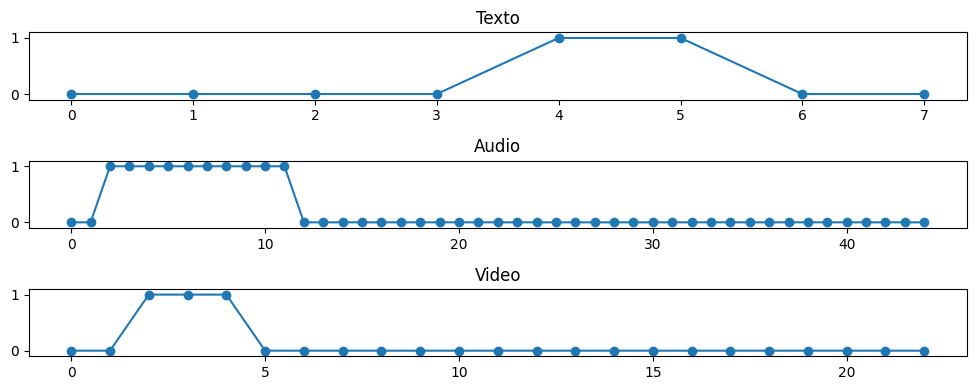

Label: 2


In [4]:
sample = train_ds[0]

def active_line(L, seg):
    arr = np.zeros(L)
    arr[seg[0]:seg[1]] = 1
    return arr

Lt = sample["text_length"]
La = sample["audio_length"]
Lv = sample["video_length"]

fig, axes = plt.subplots(3, 1, figsize=(10, 4), sharex=False)
axes[0].plot(active_line(Lt, sample["text_seg"]), marker="o")
axes[0].set_title("Texto")
axes[0].set_ylim(-0.1, 1.1)

axes[1].plot(active_line(La, sample["audio_seg"]), marker="o")
axes[1].set_title("Audio")
axes[1].set_ylim(-0.1, 1.1)

axes[2].plot(active_line(Lv, sample["video_seg"]), marker="o")
axes[2].set_title("Video")
axes[2].set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.show()

print("Label:", int(sample["label"]))

#### **4. Bloques base**

Antes de comparar arquitecturas completas, el cuaderno introduce un conjunto de **bloques base** que fijan el vocabulario computacional común de todos los modelos. Estos componentes, codificación posicional,atención cruzada, proyecciones temporales y estrategias de *pooling* enmascarado no deben entenderse como simples detalles de implementación, sino como las piezas mínimas necesarias para representar secuencias multimodales con longitudes distintas y con regiones informativas potencialmente desalineadas.

Esto hace visible que arquitecturas como **fusión tardía**, **MulT-lite** y **SPT-lite** no difieren únicamente en tamaño o profundidad, sino en la **forma en que organizan la interacción entre modalidades**. En este sentido, los bloques base definen el espacio común sobre el cual luego se introducen decisiones más específicas de fusión, atención intermodal o compresión estructural.

##notas al código
componentes básicos del modelo
1. Positional Encoding
   ↓
2. Transformer Encoder
   ↓
3. Cross Attention
   ↓
4. Temporal Convolution
   ↓
5. Mean Pooling
TransformerBlock:Texto mira Texto
CrossAttentionBlock: Texto mira Video
TemporalConv1D: Modela vecindad temporal.
Ejemplo: frame 1
frame 2
frame 3
aprende patrones locales: caminar
levantar brazo
golpear pelota

In [5]:
# 4. Bloques base

class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0), persistent=False)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class FeedForward(nn.Module):
    def __init__(self, d_model: int, mult: int = 4, dropout: float = 0.1):
        super().__init__()
        hidden = d_model * mult
        self.net = nn.Sequential(
            nn.Linear(d_model, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, d_model),
        )

    def forward(self, x):
        return self.net(x)

class TransformerBlock(nn.Module):
    def __init__(self, d_model: int, num_heads: int, ff_mult: int, dropout: float):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.ln2 = nn.LayerNorm(d_model)
        self.ff = FeedForward(d_model, ff_mult, dropout)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, key_padding_mask=None):
        h = self.ln1(x)
        out, _ = self.attn(h, h, h, key_padding_mask=(~key_padding_mask if key_padding_mask is not None else None))
        x = x + self.drop(out)
        x = x + self.drop(self.ff(self.ln2(x)))
        return x

class CrossAttentionBlock(nn.Module):
    def __init__(self, d_model: int, num_heads: int, ff_mult: int, dropout: float):
        super().__init__()
        self.ln_q = nn.LayerNorm(d_model)
        self.ln_kv = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.ln_ff = nn.LayerNorm(d_model)
        self.ff = FeedForward(d_model, ff_mult, dropout)
        self.drop = nn.Dropout(dropout)

    def forward(self, q_in, kv_in, kv_mask=None, return_weights=False):
        q = self.ln_q(q_in)
        kv = self.ln_kv(kv_in)
        out, weights = self.attn(
            q, kv, kv,
            key_padding_mask=(~kv_mask if kv_mask is not None else None),
            need_weights=return_weights,
            average_attn_weights=True,
        )
        x = q_in + self.drop(out)
        x = x + self.drop(self.ff(self.ln_ff(x)))
        if return_weights:
            return x, weights
        return x

class TemporalConv1D(nn.Module):
    def __init__(self, d_in: int, d_out: int, kernel_size: int = 3):
        super().__init__()
        pad = kernel_size // 2
        self.conv = nn.Conv1d(d_in, d_out, kernel_size=kernel_size, padding=pad)

    def forward(self, x):
        return self.conv(x.transpose(1, 2)).transpose(1, 2)

def mean_pool_masked(x, mask):
    m = mask.float().unsqueeze(-1)
    return (x * m).sum(dim=1) / m.sum(dim=1).clamp_min(1.0)

#### **5. Baseline fusión tardía**

El modelo de **fusión tardía** funciona como línea de base conceptual y experimental. Su lógica es sencilla: cada modalidad se procesa de manera independiente, se obtiene un resumen por modalidad y solo al final esos resúmenes se concatenan para realizar la predicción. Esta estrategia resulta útil porque separa con claridad el problema del **modelado unimodal** del problema de la **decisión multimodal**, y por eso constituye una referencia razonable para medir cuánto aportan arquitecturas más sofisticadas.

Sin embargo, su principal limitación aparece precisamente en el escenario que motiva este cuaderno: **secuencias no alineadas**. Cuando la información relevante se distribuye en momentos distintos de texto, audio y video, resumir cada modalidad antes de permitir interacción puede implicar una pérdida irreversible de estructura temporal. 

En otras palabras, la  fusión tardía ofrece una referencia estable y fácil de interpretar, pero también representa el tipo de aproximación que puede quedarse corta cuando la predicción depende de relaciones intermodales finas y asincrónicas. Por eso, más que un competidor definitivo, este baseline debe leerse como el punto de partida contra el cual evaluar si la **atención intermodal** realmente añade valor.


In [ ]:
se combinan luego que se procesan .
torch.cat(
    [zt, za, zv],
    dim=-1
)

In [6]:
# 5. Fusión tardía baseline

class TinySeqEncoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, ff_mult, dropout):
        super().__init__()
        self.is_text = vocab_size is not None
        if self.is_text:
            self.embed = nn.Embedding(vocab_size, d_model)
        self.pos = SinusoidalPositionalEncoding(d_model, 512)
        self.block = TransformerBlock(d_model, num_heads, ff_mult, dropout)

    def forward(self, x, mask):
        if self.is_text:
            x = self.embed(x)
        x = self.pos(x)
        x = self.block(x, mask)
        return mean_pool_masked(x, mask)

class LateFusionBaseline(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.text_enc = TinySeqEncoder(cfg.vocab_size, cfg.d_model, cfg.num_heads, cfg.ff_mult, cfg.dropout)
        self.audio_enc = TinySeqEncoder(None, cfg.d_model, cfg.num_heads, cfg.ff_mult, cfg.dropout)
        self.video_enc = TinySeqEncoder(None, cfg.d_model, cfg.num_heads, cfg.ff_mult, cfg.dropout)
        self.cls = nn.Sequential(
            nn.LayerNorm(3 * cfg.d_model),
            nn.Linear(3 * cfg.d_model, cfg.num_classes)
        )

    def forward(self, batch):
        zt = self.text_enc(batch["text_tokens"], batch["text_mask"])
        za = self.audio_enc(batch["audio"], batch["audio_mask"])
        zv = self.video_enc(batch["video"], batch["video_mask"])
        logits = self.cls(torch.cat([zt, za, zv], dim=-1))
        return {"logits": logits}

#### **6. MulT-lite con visualización de atención**

**MulT-lite** introduce el cambio conceptual más importante del cuaderno: en lugar de resumir cada modalidad por separado y fusionarlas solo al final, permite que una modalidad **consulte dinámicamente a otra mediante atención cruzada**. En esta implementación, texto, audio y video no se tratan como secuencias independientes que solo convergen en la capa de clasificación, sino como fuentes de evidencia que pueden influirse mutuamente durante la construcción de la representación. Esa es precisamente la intuición central de la atención intermodal en secuencias no alineadas: la información útil no siempre está sincronizada, por lo que el modelo debe aprender **dónde buscarla** en otra modalidad.

Además del `forward` estándar para clasificación, esta versión incluye un mecanismo para **extraer matrices de atención** en relaciones concretas, en particular **texto <- audio** y **texto <- video**. Esto permite pasar desde una evaluación puramente cuantitativa a una lectura más interpretativa del modelo. Las matrices de atención no deben entenderse como una explicación exhaustiva del razonamiento interno, pero sí como una señal útil para examinar si el modelo está concentrando peso sobre regiones temporalmente plausibles de las modalidades fuente. 

En ese sentido, la visualización de atención cumple una función metodológica importante: no solo preguntar si **MulT-lite** mejora el rendimiento, sino también observar **cómo organiza la interacción intermodal** cuando las secuencias están desfasadas.


In [7]:
# 6. MulT-lite

class MulTLite(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        D, H, M, P = cfg.d_model, cfg.num_heads, cfg.ff_mult, cfg.dropout

        self.text_embed = nn.Embedding(cfg.vocab_size, D)
        self.text_proj = TemporalConv1D(D, D, 1)
        self.audio_proj = TemporalConv1D(D, D, 3)
        self.video_proj = TemporalConv1D(D, D, 3)

        self.pos = SinusoidalPositionalEncoding(D, max(cfg.max_text_len, cfg.max_audio_len, cfg.max_video_len) + 8)

        self.v_to_t = CrossAttentionBlock(D, H, M, P)
        self.a_to_t = CrossAttentionBlock(D, H, M, P)
        self.t_to_a = CrossAttentionBlock(D, H, M, P)
        self.v_to_a = CrossAttentionBlock(D, H, M, P)
        self.t_to_v = CrossAttentionBlock(D, H, M, P)
        self.a_to_v = CrossAttentionBlock(D, H, M, P)

        self.final_t = TransformerBlock(2 * D, H, M, P)
        self.final_a = TransformerBlock(2 * D, H, M, P)
        self.final_v = TransformerBlock(2 * D, H, M, P)

        self.cls = nn.Sequential(
            nn.LayerNorm(6 * D),
            nn.Linear(6 * D, cfg.num_classes)
        )

    def encode_modalities(self, batch):
        t = self.pos(self.text_proj(self.text_embed(batch["text_tokens"])))
        a = self.pos(self.audio_proj(batch["audio"]))
        v = self.pos(self.video_proj(batch["video"]))
        return t, a, v

    def forward(self, batch):
        t, a, v = self.encode_modalities(batch)
        tm, am, vm = batch["text_mask"], batch["audio_mask"], batch["video_mask"]

        zt = self.final_t(torch.cat([self.v_to_t(t, v, vm), self.a_to_t(t, a, am)], dim=-1), tm)
        za = self.final_a(torch.cat([self.t_to_a(a, t, tm), self.v_to_a(a, v, vm)], dim=-1), am)
        zv = self.final_v(torch.cat([self.t_to_v(v, t, tm), self.a_to_v(v, a, am)], dim=-1), vm)

        pooled = torch.cat([
            mean_pool_masked(zt, tm),
            mean_pool_masked(za, am),
            mean_pool_masked(zv, vm),
        ], dim=-1)

        logits = self.cls(pooled)
        return {"logits": logits}

    @torch.no_grad()
    def get_attention_maps(self, batch):
        self.eval()
        t, a, v = self.encode_modalities(batch)
        tm, am, vm = batch["text_mask"], batch["audio_mask"], batch["video_mask"]

        _, attn_ta = self.a_to_t(t, a, am, return_weights=True)
        _, attn_tv = self.v_to_t(t, v, vm, return_weights=True)

        return {
            "text_from_audio": attn_ta,  # [B, T_text, T_audio]
            "text_from_video": attn_tv,  # [B, T_text, T_video]
        }

#### **7. SPT-lite seguro**

SPT-lite se introduce como una variante que busca preservar la capacidad de interacción multimodal de la atención intermodal (cross-modal attention), pero con una organización más eficiente de la información. Su motivación no es únicamente mejorar rendimiento, sino también explorar una arquitectura en la que la secuencia original se procesa mediante estados ocultos comprimidos, combinando etapas de **Input Attention** (atención de entrada), **Cross Attention** (atención cruzada) y **Self Attention** (autoatención). En ese sentido, el modelo representa una respuesta al problema clásico de los transformers multimodales: cómo mantener potencia expresiva sin asumir que toda interacción densa entre secuencias largas es computacionalmente sostenible

A veces se podria producir valores `NaN` debido a un problema numérico frecuente en escenarios con *padding* y atención local. Eso implicaba que algunas consultas quedaban asociadas a filas completamente enmascaradas, es decir, sin ninguna clave válida sobre la cual distribuir atención. Para evitar ese comportamiento degenerado, esta implementación utiliza una variante **segura por ejemplo**, que garantiza explícitamente la existencia de al menos una *key* válida por *query*. 

Este ajuste no cambia la intuición central del modelo, pero sí vuelve la comparación experimental más confiable, al asegurar que cualquier diferencia observada entre la **fusión tardía**, **MulT-lite** y **SPT-lite** se deba a decisiones arquitectónicas y no a inestabilidades numéricas de la implementación.


In [8]:
# 7. SPT-lite seguro

def build_safe_local_indices(q_len: int, valid_k: int, radius: int):
    idx_list = []
    for q in range(q_len):
        center = int(round((q / max(q_len - 1, 1)) * max(valid_k - 1, 0)))
        left = max(0, center - radius)
        right = min(valid_k, center + radius + 1)
        if left >= right:
            left, right = 0, max(1, valid_k)
        idx_list.append((left, right))
    return idx_list

class SafeSparsePhasedAttention(nn.Module):
    def __init__(self, d_model, num_heads, ff_mult, dropout, radius=4):
        super().__init__()
        self.ca = CrossAttentionBlock(d_model, num_heads, ff_mult, dropout)
        self.radius = radius

    def forward(self, h, x, x_mask):
        outs = []
        B = h.size(0)
        for b in range(B):
            valid_k = int(x_mask[b].sum().item())
            valid_k = max(1, valid_k)

            hb = h[b:b+1]
            xb = x[b:b+1, :valid_k]

            local_ranges = build_safe_local_indices(hb.size(1), valid_k, self.radius)

            qb = self.ca.ln_q(hb)
            kvb = self.ca.ln_kv(xb)

            rows = []
            for qi, (l, r) in enumerate(local_ranges):
                q_i = qb[:, qi:qi+1, :]
                kv_i = kvb[:, l:r, :]
                out_i, _ = self.ca.attn(q_i, kv_i, kv_i)
                rows.append(out_i)

            out_local = torch.cat(rows, dim=1)
            y = hb + self.ca.drop(out_local)
            y = y + self.ca.drop(self.ca.ff(self.ca.ln_ff(y)))
            outs.append(y)

        return torch.cat(outs, dim=0)

class SPTLite(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        D, H, M, P = cfg.d_model, cfg.num_heads, cfg.ff_mult, cfg.dropout

        self.text_embed = nn.Embedding(cfg.vocab_size, D)
        self.text_pos = SinusoidalPositionalEncoding(D, cfg.max_text_len + 8)
        self.audio_pos = SinusoidalPositionalEncoding(D, cfg.max_audio_len + 8)
        self.video_pos = SinusoidalPositionalEncoding(D, cfg.max_video_len + 8)

        ht = max(2, cfg.max_text_len // cfg.hidden_ratio)
        ha = max(2, cfg.max_audio_len // cfg.hidden_ratio)
        hv = max(2, cfg.max_video_len // cfg.hidden_ratio)

        self.h_t = nn.Parameter(torch.randn(1, ht, D))
        self.h_a = nn.Parameter(torch.randn(1, ha, D))
        self.h_v = nn.Parameter(torch.randn(1, hv, D))

        self.input_t = SafeSparsePhasedAttention(D, H, M, P, radius=3)
        self.input_a = SafeSparsePhasedAttention(D, H, M, P, radius=5)
        self.input_v = SafeSparsePhasedAttention(D, H, M, P, radius=4)

        self.cross_ta = SafeSparsePhasedAttention(D, H, M, P, radius=3)
        self.cross_tv = SafeSparsePhasedAttention(D, H, M, P, radius=3)
        self.cross_at = SafeSparsePhasedAttention(D, H, M, P, radius=3)
        self.cross_av = SafeSparsePhasedAttention(D, H, M, P, radius=3)
        self.cross_vt = SafeSparsePhasedAttention(D, H, M, P, radius=3)
        self.cross_va = SafeSparsePhasedAttention(D, H, M, P, radius=3)

        self.self_t = TransformerBlock(D, H, M, P)
        self.self_a = TransformerBlock(D, H, M, P)
        self.self_v = TransformerBlock(D, H, M, P)

        self.num_layers = cfg.num_layers
        self.cls = nn.Sequential(
            nn.LayerNorm(3 * D),
            nn.Linear(3 * D, cfg.num_classes)
        )

    def forward(self, batch):
        B = batch["text_tokens"].size(0)
        t = self.text_pos(self.text_embed(batch["text_tokens"]))
        a = self.audio_pos(batch["audio"])
        v = self.video_pos(batch["video"])

        tm, am, vm = batch["text_mask"], batch["audio_mask"], batch["video_mask"]

        ht = self.h_t.expand(B, -1, -1)
        ha = self.h_a.expand(B, -1, -1)
        hv = self.h_v.expand(B, -1, -1)

        for _ in range(self.num_layers):
            ht_i = self.input_t(ht, t, tm)
            ha_i = self.input_a(ha, a, am)
            hv_i = self.input_v(hv, v, vm)

            ht = self.self_t(
                self.cross_ta(ht_i, ha_i, torch.ones(ha_i.shape[:2], dtype=torch.bool, device=ha_i.device)) +
                self.cross_tv(ht_i, hv_i, torch.ones(hv_i.shape[:2], dtype=torch.bool, device=hv_i.device))
            )
            ha = self.self_a(
                self.cross_at(ha_i, ht_i, torch.ones(ht_i.shape[:2], dtype=torch.bool, device=ht_i.device)) +
                self.cross_av(ha_i, hv_i, torch.ones(hv_i.shape[:2], dtype=torch.bool, device=hv_i.device))
            )
            hv = self.self_v(
                self.cross_vt(hv_i, ht_i, torch.ones(ht_i.shape[:2], dtype=torch.bool, device=ht_i.device)) +
                self.cross_va(hv_i, ha_i, torch.ones(ha_i.shape[:2], dtype=torch.bool, device=ha_i.device))
            )

        pooled = torch.cat([ht.mean(dim=1), ha.mean(dim=1), hv.mean(dim=1)], dim=-1)
        logits = self.cls(pooled)
        return {"logits": logits}

#### **8. Entrenamiento, evaluación y utilidades**

Esta sección organiza el cuaderno como un experimento comparativo y no solo como una implementación de modelos. Para ello, incorpora un conjunto de utilidades que permiten evaluar simultáneamente **rendimiento, estabilidad y costo computacional**. En particular, se añade el **conteo de parámetros** para estimar la capacidad efectiva de cada arquitectura, junto con el **tiempo por época**, de modo que la comparación entre **Fusión tardía**, **MulT-lite** y **SPT-lite** no se reduzca únicamente a métricas predictivas.

Desde el punto de vista metodológico, también se incluyen salvaguardas contra **pérdidas no finitas**, con el fin de evitar que problemas numéricos distorsionen la interpretación de resultados. A esto se suma una evaluación separada en **validación** y **test**, así como métricas de desempeño más informativas que la sola exactitud, en particular **F1-macro**, que resulta útil cuando interesa observar si el comportamiento del modelo es equilibrado entre clases. 

Finalmente, la incorporación de una **matriz de confusión** permite un análisis más fino del error, mostrando si las diferencias entre modelos reflejan mejoras globales o si se concentran en clases específicas. En conjunto, esta sección convierte el notebook en una herramienta de análisis experimental más sólida y adecuada para una lectura de nivel posgrado.


In [9]:
#8. Entrenamiento y evaluación

def move_batch_to_device(batch, device):
    return {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

@torch.no_grad()
def compute_metrics(logits, labels, num_classes):
    pred = logits.argmax(dim=-1)
    acc = (pred == labels).float().mean().item()

    f1s = []
    for c in range(num_classes):
        tp = ((pred == c) & (labels == c)).sum().float()
        fp = ((pred == c) & (labels != c)).sum().float()
        fn = ((pred != c) & (labels == c)).sum().float()
        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)
        f1s.append(float(f1.cpu()))
    return {"acc": acc, "f1_macro": float(np.mean(f1s))}

def train_one_epoch(model, loader, optimizer, device, cfg):
    model.train()
    losses = []
    for batch in loader:
        batch = move_batch_to_device(batch, device)
        optimizer.zero_grad()
        out = model(batch)
        loss = F.cross_entropy(out["logits"], batch["labels"])

        if not torch.isfinite(loss):
            print("Pérdida no finita; se omite el batch.")
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        optimizer.step()
        losses.append(float(loss.detach().cpu()))

    return float(np.mean(losses)) if losses else float("nan")

@torch.no_grad()
def evaluate_classifier(model, loader, device, cfg):
    model.eval()
    losses = []
    metrics = []

    for batch in loader:
        batch = move_batch_to_device(batch, device)
        out = model(batch)
        loss = F.cross_entropy(out["logits"], batch["labels"])

        if not torch.isfinite(loss):
            continue

        losses.append(float(loss.detach().cpu()))
        metrics.append(compute_metrics(out["logits"], batch["labels"], cfg.num_classes))

    if not losses:
        return {"loss": float("nan"), "acc": 0.0, "f1_macro": 0.0}

    return {
        "loss": float(np.mean(losses)),
        "acc": float(np.mean([m["acc"] for m in metrics])),
        "f1_macro": float(np.mean([m["f1_macro"] for m in metrics])),
    }

@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    for batch in loader:
        batch = move_batch_to_device(batch, device)
        logits = model(batch)["logits"]
        pred = logits.argmax(dim=-1)
        y_true.extend(batch["labels"].cpu().tolist())
        y_pred.extend(pred.cpu().tolist())
    return np.array(y_true), np.array(y_pred)

def confusion_matrix_manual(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

def run_training(model, model_name, train_loader, val_loader, test_loader, device, cfg):
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    history = []

    for epoch in range(cfg.epochs):
        t0 = time.time()
        train_loss = train_one_epoch(model, train_loader, optimizer, device, cfg)
        val_stats = evaluate_classifier(model, val_loader, device, cfg)
        elapsed = time.time() - t0

        row = {
            "epoch": epoch + 1,
            "train_loss": round(train_loss, 4) if np.isfinite(train_loss) else np.nan,
            "val_loss": round(val_stats["loss"], 4) if np.isfinite(val_stats["loss"]) else np.nan,
            "val_acc": round(val_stats["acc"], 4),
            "val_f1_macro": round(val_stats["f1_macro"], 4),
            "epoch_seconds": round(elapsed, 2),
        }
        history.append(row)
        print(f"{model_name} | {row}")

    hist_df = pd.DataFrame(history)

    test_stats = evaluate_classifier(model, test_loader, device, cfg)
    y_true, y_pred = collect_predictions(model, test_loader, device)
    cm = confusion_matrix_manual(y_true, y_pred, cfg.num_classes)

    summary = {
        "modelo": model_name,
        "params": count_parameters(model),
        "best_val_acc": float(hist_df["val_acc"].max()),
        "best_val_f1": float(hist_df["val_f1_macro"].max()),
        "final_val_acc": float(hist_df.iloc[-1]["val_acc"]),
        "final_val_f1": float(hist_df.iloc[-1]["val_f1_macro"]),
        "test_acc": round(test_stats["acc"], 4),
        "test_f1": round(test_stats["f1_macro"], 4),
        "avg_epoch_sec": round(float(hist_df["epoch_seconds"].mean()), 2),
    }

    return hist_df, summary, cm

#### **9. Entrenar modelos**

In [10]:
late_fusion = LateFusionBaseline(CFG).to(DEVICE)
mult_lite = MulTLite(CFG).to(DEVICE)
spt_lite = SPTLite(CFG).to(DEVICE)

late_df, late_summary, late_cm = run_training(late_fusion, "Late Fusion", train_loader, val_loader, test_loader, DEVICE, CFG)
mult_df, mult_summary, mult_cm = run_training(mult_lite, "MulT-lite", train_loader, val_loader, test_loader, DEVICE, CFG)
spt_df, spt_summary, spt_cm = run_training(spt_lite, "SPT-lite", train_loader, val_loader, test_loader, DEVICE, CFG)

Late Fusion | {'epoch': 1, 'train_loss': 0.2136, 'val_loss': 0.0413, 'val_acc': 1.0, 'val_f1_macro': 0.9167, 'epoch_seconds': 1.48}
Late Fusion | {'epoch': 2, 'train_loss': 0.0, 'val_loss': 0.0445, 'val_acc': 1.0, 'val_f1_macro': 0.9167, 'epoch_seconds': 0.83}
Late Fusion | {'epoch': 3, 'train_loss': 0.0, 'val_loss': 0.045, 'val_acc': 1.0, 'val_f1_macro': 0.9167, 'epoch_seconds': 1.0}
Late Fusion | {'epoch': 4, 'train_loss': 0.0, 'val_loss': 0.0454, 'val_acc': 1.0, 'val_f1_macro': 0.9167, 'epoch_seconds': 1.05}
Late Fusion | {'epoch': 5, 'train_loss': 0.0, 'val_loss': 0.0455, 'val_acc': 1.0, 'val_f1_macro': 0.9167, 'epoch_seconds': 1.09}
Late Fusion | {'epoch': 6, 'train_loss': 0.0, 'val_loss': 0.0457, 'val_acc': 1.0, 'val_f1_macro': 0.9167, 'epoch_seconds': 1.22}
Late Fusion | {'epoch': 7, 'train_loss': 0.0, 'val_loss': 0.0461, 'val_acc': 1.0, 'val_f1_macro': 0.9167, 'epoch_seconds': 1.03}
Late Fusion | {'epoch': 8, 'train_loss': 0.0, 'val_loss': 0.0465, 'val_acc': 1.0, 'val_f1_macro'

#### **10. Curvas de entrenamiento**

Las curvas de esta sección cumplen una función analítica central: permiten observar no solo **qué modelo rinde mejor al final**, sino también **cómo aprende** a lo largo del entrenamiento. En lugar de limitar la comparación a una única métrica agregada, se presentan conjuntamente la **pérdida de entrenamiento**, la **pérdida de validación**, la **accuracy de validación** y el **F1-macro de validación**. Esta combinación ofrece una lectura más completa del comportamiento de cada arquitectura, distinguiendo entre ajuste al conjunto de entrenamiento, estabilidad en validación y equilibrio entre clases.

Desde una perspectiva metodológica, estas curvas son importantes porque ayudan a interpretar diferencias que una tabla final por sí sola podría ocultar. Por ejemplo, un modelo puede alcanzar una accuracy final similar a otro, pero con trayectorias de convergencia distintas, mayor variabilidad o peor balance entre clases. En ese sentido, las curvas permiten evaluar si **Fusión tardía**, **MulT-lite** y **SPT-lite** difieren únicamente en el punto final de rendimiento o también en la dinámica mediante la cual construyen sus representaciones. 


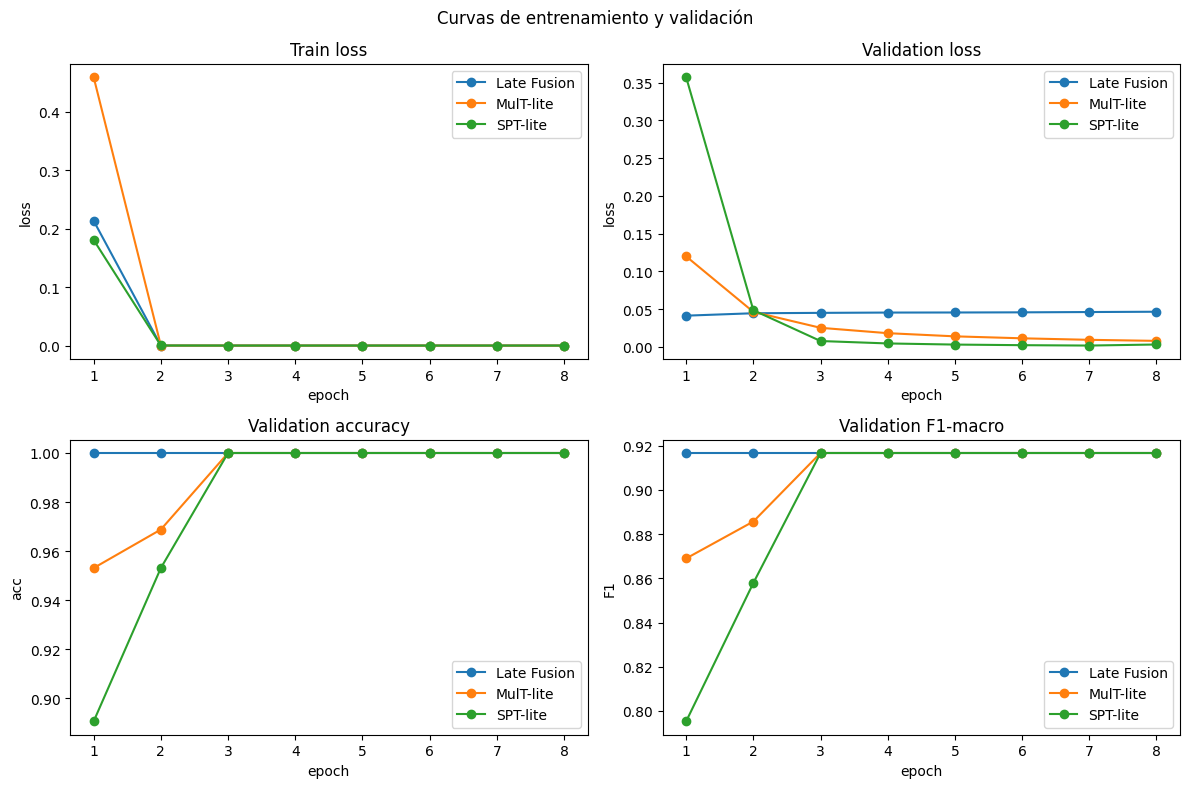

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# train loss
axes[0, 0].plot(late_df["epoch"], late_df["train_loss"], marker="o", label="Late Fusion")
axes[0, 0].plot(mult_df["epoch"], mult_df["train_loss"], marker="o", label="MulT-lite")
axes[0, 0].plot(spt_df["epoch"], spt_df["train_loss"], marker="o", label="SPT-lite")
axes[0, 0].set_title("Train loss")
axes[0, 0].set_xlabel("epoch")
axes[0, 0].set_ylabel("loss")
axes[0, 0].legend()

# val loss
axes[0, 1].plot(late_df["epoch"], late_df["val_loss"], marker="o", label="Late Fusion")
axes[0, 1].plot(mult_df["epoch"], mult_df["val_loss"], marker="o", label="MulT-lite")
axes[0, 1].plot(spt_df["epoch"], spt_df["val_loss"], marker="o", label="SPT-lite")
axes[0, 1].set_title("Validation loss")
axes[0, 1].set_xlabel("epoch")
axes[0, 1].set_ylabel("loss")
axes[0, 1].legend()

# val acc
axes[1, 0].plot(late_df["epoch"], late_df["val_acc"], marker="o", label="Late Fusion")
axes[1, 0].plot(mult_df["epoch"], mult_df["val_acc"], marker="o", label="MulT-lite")
axes[1, 0].plot(spt_df["epoch"], spt_df["val_acc"], marker="o", label="SPT-lite")
axes[1, 0].set_title("Validation accuracy")
axes[1, 0].set_xlabel("epoch")
axes[1, 0].set_ylabel("acc")
axes[1, 0].legend()

# val f1
axes[1, 1].plot(late_df["epoch"], late_df["val_f1_macro"], marker="o", label="Late Fusion")
axes[1, 1].plot(mult_df["epoch"], mult_df["val_f1_macro"], marker="o", label="MulT-lite")
axes[1, 1].plot(spt_df["epoch"], spt_df["val_f1_macro"], marker="o", label="SPT-lite")
axes[1, 1].set_title("Validation F1-macro")
axes[1, 1].set_xlabel("epoch")
axes[1, 1].set_ylabel("F1")
axes[1, 1].legend()

plt.suptitle("Curvas de entrenamiento y validación")
plt.tight_layout()
plt.show()

#### **11. Tabla final**


In [12]:
paper_table = pd.DataFrame([late_summary, mult_summary, spt_summary])
paper_table = paper_table[
    ["modelo", "params", "best_val_acc", "best_val_f1", "final_val_acc", "final_val_f1", "test_acc", "test_f1", "avg_epoch_sec"]
]
paper_table

,modelo,params,best_val_acc,best_val_f1,final_val_acc,final_val_f1,test_acc,test_f1,avg_epoch_sec
0,Late Fusion,858883,1.0,0.9167,1.0,0.9167,1.0000,1.0000,1.07
1,MulT-lite,3941507,1.0,0.9167,1.0,0.9167,0.9844,0.9722,4.21
2,SPT-lite,2648323,1.0,0.9167,1.0,0.9167,1.0000,1.0000,54.42


In [13]:
def dataframe_to_markdown(df: pd.DataFrame):
    return df.to_markdown(index=False)

print(dataframe_to_markdown(paper_table))

| modelo      |   params |   best_val_acc |   best_val_f1 |   final_val_acc |   final_val_f1 |   test_acc |   test_f1 |   avg_epoch_sec |
|:------------|---------:|---------------:|--------------:|----------------:|---------------:|-----------:|----------:|----------------:|
| Late Fusion |   858883 |              1 |        0.9167 |               1 |         0.9167 |     1      |    1      |            1.07 |
| MulT-lite   |  3941507 |              1 |        0.9167 |               1 |         0.9167 |     0.9844 |    0.9722 |            4.21 |
| SPT-lite    |  2648323 |              1 |        0.9167 |               1 |         0.9167 |     1      |    1      |           54.42 |


#### **12. Barras finales comparativas**





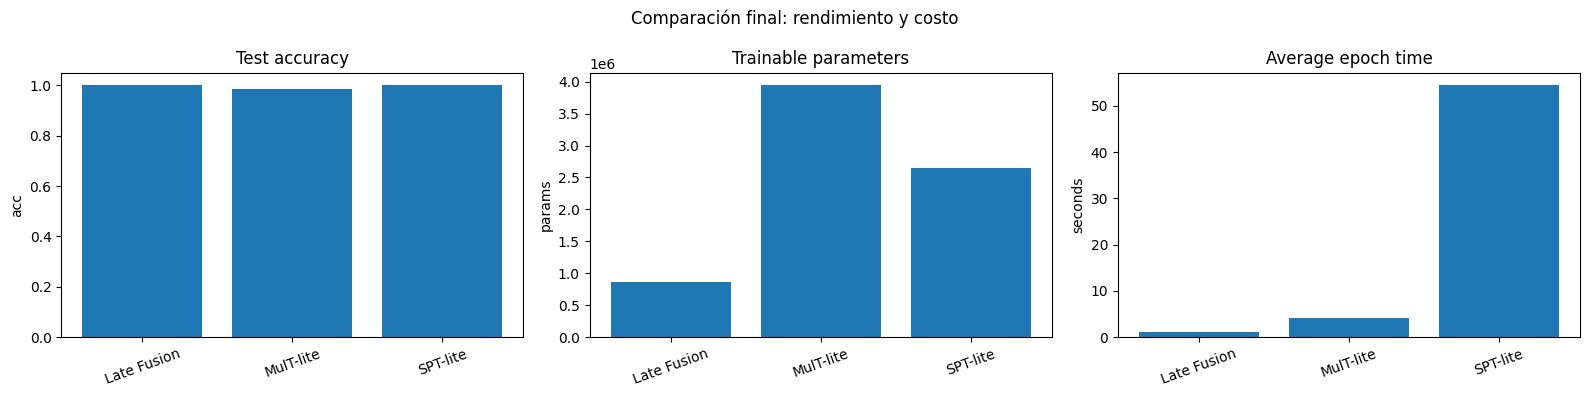

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(paper_table["modelo"], paper_table["test_acc"])
axes[0].set_title("Test accuracy")
axes[0].set_ylabel("acc")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(paper_table["modelo"], paper_table["params"])
axes[1].set_title("Trainable parameters")
axes[1].set_ylabel("params")
axes[1].tick_params(axis="x", rotation=20)

axes[2].bar(paper_table["modelo"], paper_table["avg_epoch_sec"])
axes[2].set_title("Average epoch time")
axes[2].set_ylabel("seconds")
axes[2].tick_params(axis="x", rotation=20)

plt.suptitle("Comparación final: rendimiento y costo")
plt.tight_layout()
plt.show()

#### **13. Matrices de confusión**

Las matrices de confusión permiten complementar las métricas agregadas con una lectura más fina del comportamiento de cada arquitectura. Mientras medidas como **accuracy** o **F1-macro** resumen el desempeño global, la matriz de confusión muestra **cómo se distribuyen los aciertos y errores entre clases**, lo que resulta especialmente útil cuando interesa distinguir entre una mejora general y una mejora localizada en categorías específicas.

Desde una perspectiva metodológica, esta sección ayuda a responder una pregunta importante: si un modelo supera a otro, ¿lo hace porque representa mejor el problema en su conjunto, o porque simplemente favorece una clase y sacrifica otras? 

En este sentido, las matrices de confusión permiten observar si la **fusión tardía**, **MulT-lite** y **SPT-lite** presentan patrones de error distintos, si ciertas clases siguen siendo sistemáticamente ambiguas o si la atención intermodal contribuye efectivamente a una discriminación más equilibrada. 


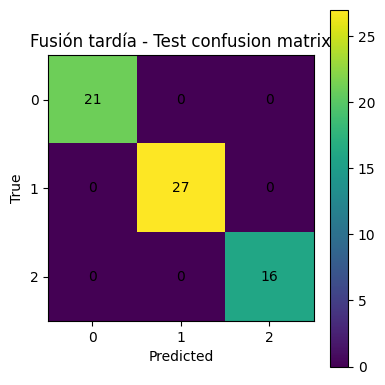

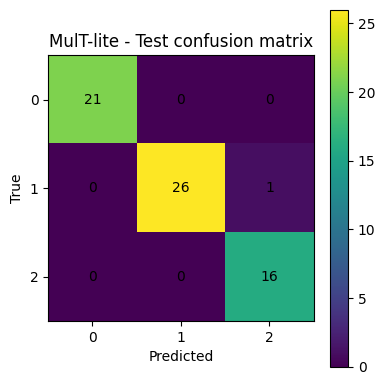

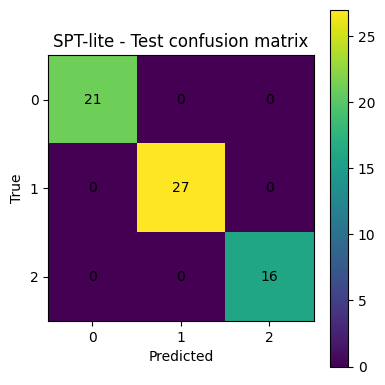

In [15]:
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(4, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()
    ticks = range(cm.shape[0])
    plt.xticks(ticks)
    plt.yticks(ticks)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(late_cm, "Fusión tardía - Test confusion matrix")
plot_confusion_matrix(mult_cm, "MulT-lite - Test confusion matrix")
plot_confusion_matrix(spt_cm, "SPT-lite - Test confusion matrix")

#### **14. Visualización de atención para MulT-lite**

Esta sección constituye uno de los puntos más relevantes del cuaderno, porque permite pasar desde una comparación puramente métrica a una lectura más interpretativa del comportamiento del modelo. En particular, se selecciona una muestra del conjunto de validación y se visualizan dos mapas de atención: **texto atendiendo audio** y **texto atendiendo video**. Estas representaciones muestran cómo las posiciones de la secuencia textual distribuyen su atención sobre las posiciones temporales de otra modalidad, ofreciendo una aproximación a la forma en que **MulT-lite** organiza la interacción intermodal.

La lectura de estos mapas debe hacerse de manera estructurada: el **eje vertical** corresponde a las posiciones de la secuencia objetivo, en este caso el texto; el **eje horizontal** representa las posiciones temporales de la modalidad fuente, ya sea audio o video y la intensidad del color indica la magnitud relativa del peso de atención asignado. 

Desde esta perspectiva, la visualización no busca una diagonal perfecta, como ocurriría en un problema estrictamente alineado, sino patrones selectivos que reflejen asociaciones útiles incluso cuando las señales aparecen desfasadas en el tiempo.


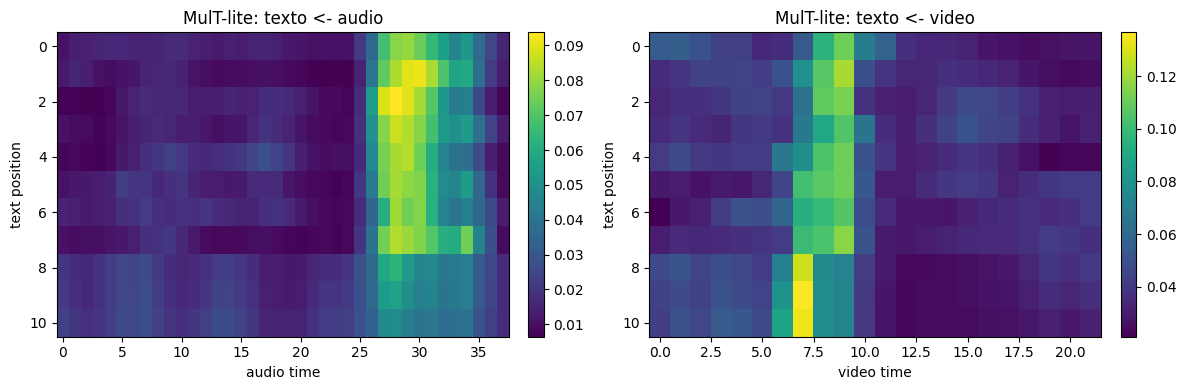

In [16]:
# seleccionar un batch pequeño de validación
small_batch = next(iter(DataLoader(val_ds, batch_size=2, shuffle=False, collate_fn=lambda b: collate_unaligned(b, CFG))))
small_batch = {k: (v.to(DEVICE) if torch.is_tensor(v) else v) for k, v in small_batch.items()}

attn_maps = mult_lite.get_attention_maps(small_batch)
attn_ta = attn_maps["text_from_audio"][0].detach().cpu().numpy()  # muestra 0
attn_tv = attn_maps["text_from_video"][0].detach().cpu().numpy()

text_len = int(small_batch["text_lengths"][0].item())
audio_len = int(small_batch["audio_lengths"][0].item())
video_len = int(small_batch["video_lengths"][0].item())

attn_ta = attn_ta[:text_len, :audio_len]
attn_tv = attn_tv[:text_len, :video_len]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im0 = axes[0].imshow(attn_ta, aspect="auto")
axes[0].set_title("MulT-lite: texto <- audio")
axes[0].set_xlabel("audio time")
axes[0].set_ylabel("text position")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(attn_tv, aspect="auto")
axes[1].set_title("MulT-lite: texto <- video")
axes[1].set_xlabel("video time")
axes[1].set_ylabel("text position")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

#### **15. Atención y segmentos informativos**

En esta sección, los mapas de atención se interpretan a la luz de los **segmentos informativos reales** de la muestra seleccionada. La superposición entre atención estimada y regiones relevantes permite pasar desde una lectura puramente visual a una lectura más analítica del comportamiento del modelo. En lugar de observar únicamente dónde se concentra el peso de atención, ahora es posible contrastar esa distribución con las zonas del ejemplo que efectivamente contienen la señal útil para la predicción.

Esta comparación resulta entonces especialmente valiosa porque permite evaluar si la atención intermodal de **MulT-lite** está capturando asociaciones plausibles entre modalidades o si, por el contrario, distribuye peso de manera poco informativa. 

Cuando los patrones de atención coinciden al menos parcialmente con los segmentos relevantes, la visualización ofrece evidencia de que el modelo no solo mejora en métricas, sino que además organiza la interacción intermodal de una forma coherente con la estructura del problema.


Segmento texto: [8, 11]
Segmento audio: [26, 36]
Segmento video: [7, 11]


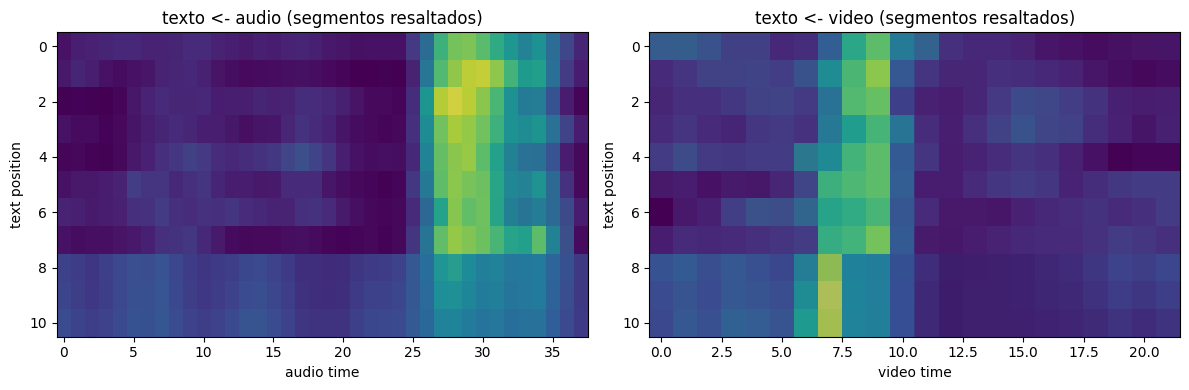

In [17]:
sample_idx = 0

t_seg = small_batch["text_seg"][sample_idx].cpu().numpy().tolist()
a_seg = small_batch["audio_seg"][sample_idx].cpu().numpy().tolist()
v_seg = small_batch["video_seg"][sample_idx].cpu().numpy().tolist()

print("Segmento texto:", t_seg)
print("Segmento audio:", a_seg)
print("Segmento video:", v_seg)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(attn_ta, aspect="auto")
axes[0].axhspan(t_seg[0]-0.5, t_seg[1]-0.5, alpha=0.2)
axes[0].axvspan(a_seg[0]-0.5, a_seg[1]-0.5, alpha=0.2)
axes[0].set_title("texto <- audio (segmentos resaltados)")
axes[0].set_xlabel("audio time")
axes[0].set_ylabel("text position")

axes[1].imshow(attn_tv, aspect="auto")
axes[1].axhspan(t_seg[0]-0.5, t_seg[1]-0.5, alpha=0.2)
axes[1].axvspan(v_seg[0]-0.5, v_seg[1]-0.5, alpha=0.2)
axes[1].set_title("texto <- video (segmentos resaltados)")
axes[1].set_xlabel("video time")
axes[1].set_ylabel("text position")

plt.tight_layout()
plt.show()

#### **16. Preguntas para discusión**

1. ¿La mejora de MulT-lite parece venir de mejor alineamiento o de mayor capacidad?
   Principalmente de mejor alineamiento. Según la teoría de MulT, las modalidades (texto, audio y video) no están perfectamente sincronizadas. El Cross-Attention permite que una modalidad encuentre información relevante en otra sin requerir alineación temporal exacta. La mejora parece provenir más de esta interacción multimodal que simplemente de tener más parámetros.
   
2. ¿SPT-lite ofrece una relación rendimiento/costo razonable?
Sí. SPT-lite incorpora modelado temporal mediante convoluciones o transformaciones ligeras, capturando dependencias temporales sin el costo completo de Cross-Attention multimodal. Representa un equilibrio entre capacidad de modelar secuencias y eficiencia computacional.
   
3. ¿La atención visualizada en MulT-lite parece diagonal, difusa o selectiva?

   Tiende a ser selectiva. En teoría, el Cross-Attention debe concentrarse en segmentos relevantes de otra modalidad. Si la atención fuera diagonal indicaría alineación casi perfecta; si fuera difusa sugeriría poca discriminación. Una atención selectiva indica que el modelo aprendió correspondencias semánticas entre modalidades.
   
4. ¿Qué parte del problema real aún no está capturada por este dataset sintético?

   No captura ruido real, ambigüedad lingüística, expresiones faciales complejas, errores de transcripción, variaciones acústicas ni desalineamientos naturales. En datasets reales el modelo debe descubrir la correspondencia multimodal por sí mismo

   
5. ¿Qué experimento harías después para acercarte a MOSI/MOSEI?
Evaluaría el modelo en datos reales multimodales. MOSI y MOSEI contienen texto, audio y video reales con etiquetas de sentimiento y emoción sería extraer una muestra. Esto permitiría estudiar si el alineamiento multimodal aprendido en el entorno sintético generaliza a situaciones reales donde existen ruido, emociones, lenguaje natural y sincronización imperfecta.

#### **17. Trabajo futuro sugerido**

**1. Controlar la comparación por capacidad del modelo.**

Una primera extensión consiste en **igualar lo más estrictamente posible el número de parámetros** entre la **fusión tardía**, **MulT-lite** y **SPT-lite**, de modo que las diferencias observadas puedan atribuirse con mayor claridad a la arquitectura y no simplemente a la capacidad representacional. El objetivo de este ejercicio es discutir si la mejora de la atención intermodal proviene realmente de un mejor modelado del desalineamiento o si está parcialmente explicada por un presupuesto paramétrico mayor.

**2. Sustituir el dataset sintético por un adaptador real.**

Una segunda línea de trabajo consiste en incorporar un adaptador para un dataset más cercano a aplicaciones reales, por ejemplo en formato **MOSI-like**, **MOSEI-like** o **IEMOCAP-like**. El propósito aquí no es solo cambiar la fuente de datos, sino examinar en qué medida las conclusiones obtenidas en el entorno sintético se mantienen cuando las modalidades contienen ruido, asincronía y ambigüedad semántica propias de un escenario real. Este ejercicio obliga además a pensar en preprocesamiento, máscaras, longitudes y criterios de evaluación más realistas.

**3. Ampliar el análisis cualitativo de atención.**
Otra extensión relevante consiste en **guardar y comparar mapas de atención de múltiples muestras**, en lugar de inspeccionar un único ejemplo. Esto permitiría estudiar si los patrones observados en **MulT-lite** son sistemáticos o si dependen de casos particulares. Como ejercicio, se puede pedir una selección de ejemplos bien clasificados y mal clasificados, acompañada de una interpretación de si la atención parece coherente con los segmentos informativos o si revela fallas recurrentes del modelo.

**4. Medir costo computacional de manera más completa.**
El cuaderno ya registra tiempo por época, pero una mejora natural es incorporar también medidas de **uso de memoria**, especialmente en GPU. Este ejercicio permitiría discutir de forma más rigurosa la relación entre expresividad y costo, comparando no solo exactitud o F1, sino también consumo de recursos. En un contexto de posgrado, esta dimensión es importante porque una arquitectura no solo debe evaluarse por su rendimiento, sino por su viabilidad bajo restricciones reales de cómputo.
